In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import random
import os
from torch.utils.data import random_split

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
cifar_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
class TaggedDataset(Dataset):
    def __init__(self, dataset, tag):
        self.dataset = dataset
        self.tag = tag
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return img, label, self.tag

In [ ]:
mnist_train_raw = datasets.MNIST(root='./data', train=True, download=True, transform=mnist_transform)
mnist_test_raw  = datasets.MNIST(root='./data', train=False, download=True, transform=mnist_transform)

cifar_train_raw = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
cifar_test_raw  = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)

mnist_train_ds = TaggedDataset(mnist_train_raw, tag=0)
mnist_test_ds  = TaggedDataset(mnist_test_raw, tag=0)
cifar_train_ds = TaggedDataset(cifar_train_raw, tag=1)
cifar_test_ds  = TaggedDataset(cifar_test_raw, tag=1)

combined_train_dataset = ConcatDataset([mnist_train_ds, cifar_train_ds])

combined_test_dataset = ConcatDataset([mnist_test_ds, cifar_test_ds])

In [ ]:
val_size = int(0.1 * len(combined_train_dataset))
train_size = len(combined_train_dataset) - val_size
train_ds, val_ds = random_split(combined_train_dataset, [train_size, val_size])

In [ ]:
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(combined_test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
class MixedMLP(nn.Module):
    def __init__(self, input_dim=28*28, output_dim=10):
        super().__init__()
        self.flat = nn.Flatten()
        
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu1 = nn.ReLU()
        
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu2 = nn.ReLU()
        
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.flat(x)
        x = self.relu1(self.bn1(self.fc1(x)))
        x = self.relu2(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x

In [ ]:
model = MixedMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15
patience = 5

valid_loss_min = np.inf
patience_counter = 0

In [ ]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels, tag in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    model.eval()
    valid_loss = 0.0
    correct_val = 0
    total_val = 0
    
    correct_mnist = 0; total_mnist = 0
    correct_cifar = 0; total_cifar = 0
    
    with torch.no_grad():
        for data, target, tag in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            
            loss_val = criterion(output, target)
            valid_loss += loss_val.item() * data.size(0)
            
            pred = output.argmax(dim=1)
            correct_val += (pred == target).sum().item()
            total_val += target.size(0)
            
            mnist_mask = (tag == 0)
            cifar_mask = (tag == 1)
            
            if mnist_mask.sum() > 0:
                correct_mnist += pred[mnist_mask].eq(target[mnist_mask]).sum().item()
                total_mnist += mnist_mask.sum().item()
            if cifar_mask.sum() > 0:
                correct_cifar += pred[cifar_mask].eq(target[cifar_mask]).sum().item()
                total_cifar += cifar_mask.sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    
    val_loss_avg = valid_loss / len(val_loader.dataset)
    val_acc = 100. * correct_val / total_val
    
    acc_mnist = 100. * correct_mnist / total_mnist if total_mnist > 0 else 0
    acc_cifar = 100. * correct_cifar / total_cifar if total_cifar > 0 else 0

    print(f'\nEpoch [{epoch+1}/{epochs}]')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss:   {val_loss_avg:.4f} | Val Acc:   {val_acc:.2f}%')
    print(f'   >>> [Domain Spec] MNIST: {acc_mnist:.2f}% | CIFAR: {acc_cifar:.2f}%')

    # Early Stopping
    if val_loss_avg <= valid_loss_min:
        print(f'Validation loss decreased ({valid_loss_min:.6f} --> {val_loss_avg:.6f}). Saving model...')
        torch.save(model.state_dict(), 'mixed_mlp_baseline.pth')
        valid_loss_min = val_loss_avg
        patience_counter = 0
    else:
        patience_counter += 1
        print(f'EarlyStopping counter: {patience_counter} out of {patience}')
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1 Training: 100%|██████████| 3094/3094 [00:50<00:00, 60.77it/s]



Epoch [1/15]
Train Loss: 1.0577 | Train Acc: 63.28%
Val Loss:   0.9596 | Val Acc:   66.35%
   >>> [Domain Spec] MNIST: 93.46% | CIFAR: 35.35%
Validation loss decreased (inf --> 0.959552). Saving model...


Epoch 2 Training: 100%|██████████| 3094/3094 [01:27<00:00, 35.28it/s]



Epoch [2/15]
Train Loss: 0.9040 | Train Acc: 68.21%
Val Loss:   0.8745 | Val Acc:   69.53%
   >>> [Domain Spec] MNIST: 96.47% | CIFAR: 38.71%
Validation loss decreased (0.959552 --> 0.874486). Saving model...


Epoch 3 Training: 100%|██████████| 3094/3094 [01:39<00:00, 31.22it/s]


...


Epoch [13/15]
Train Loss: 0.6811 | Train Acc: 75.82%
Val Loss:   0.7674 | Val Acc:   73.55%
   >>> [Domain Spec] MNIST: 97.75% | CIFAR: 45.86%
EarlyStopping counter: 2 out of 5


Epoch 14 Training: 100%|██████████| 3094/3094 [00:59<00:00, 52.23it/s]



Epoch [14/15]
Train Loss: 0.6725 | Train Acc: 76.20%
Val Loss:   0.7580 | Val Acc:   73.65%
   >>> [Domain Spec] MNIST: 97.82% | CIFAR: 46.01%
EarlyStopping counter: 3 out of 5


Epoch 15 Training: 100%|██████████| 3094/3094 [01:36<00:00, 32.15it/s]



Epoch [15/15]
Train Loss: 0.6649 | Train Acc: 76.48%
Val Loss:   0.7648 | Val Acc:   73.82%
   >>> [Domain Spec] MNIST: 97.90% | CIFAR: 46.27%
EarlyStopping counter: 4 out of 5


In [ ]:
best_model = MixedMLP().to(device)

best_model.load_state_dict(torch.load('mixed_mlp_baseline.pth'))
best_model.eval()

print("En iyi model başarıyla yüklendi!")

En iyi model başarıyla yüklendi!


Test analizi yapılıyor...

=== DETAYLI SONUÇLAR ===
Genel Doğruluk      : %71.49
MNIST Doğruluğu     : %97.79
CIFAR-10 Doğruluğu  : %45.19


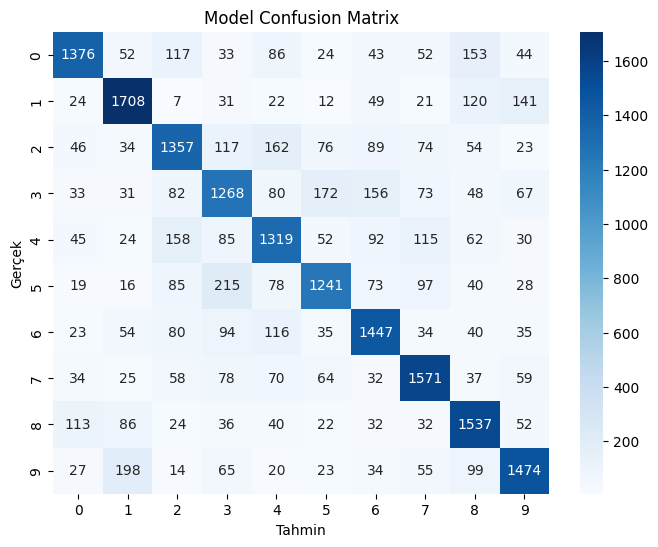


Modelin Yanlış Bildiği Örnekler:


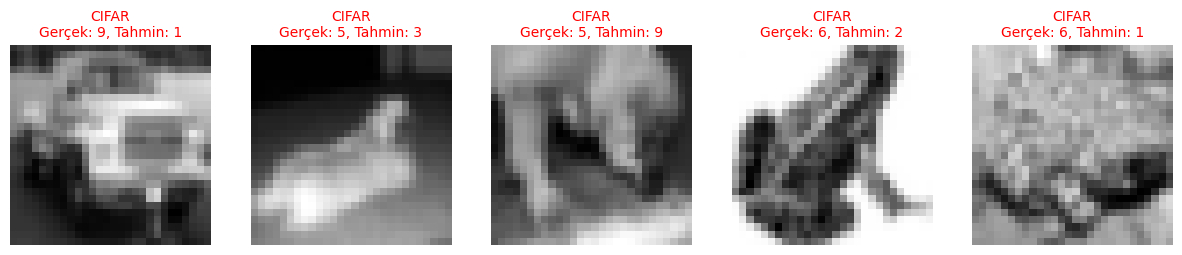

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

best_model.eval()
all_preds = []
all_targets = []
all_tags = []

correct_mnist = 0; total_mnist = 0
correct_cifar = 0; total_cifar = 0

print("Test analizi yapılıyor...")

with torch.no_grad():
    for data, target, tag in test_loader:
        data, target, tag = data.to(device), target.to(device), tag.to(device)
        
        output = best_model(data)
        pred = output.argmax(dim=1)
        
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
        all_tags.extend(tag.cpu().numpy())
        
        mnist_mask = (tag == 0)
        cifar_mask = (tag == 1)
        if mnist_mask.sum() > 0:
            correct_mnist += pred[mnist_mask].eq(target[mnist_mask]).sum().item()
            total_mnist += mnist_mask.sum().item()
        if cifar_mask.sum() > 0:
            correct_cifar += pred[cifar_mask].eq(target[cifar_mask]).sum().item()
            total_cifar += cifar_mask.sum().item()

acc_mnist = 100. * correct_mnist / total_mnist if total_mnist > 0 else 0
acc_cifar = 100. * correct_cifar / total_cifar if total_cifar > 0 else 0
overall_acc = 100. * (correct_mnist + correct_cifar) / (total_mnist + total_cifar)

print(f"\n=== DETAYLI SONUÇLAR ===")
print(f"Genel Doğruluk      : %{overall_acc:.2f}")
print(f"MNIST Doğruluğu     : %{acc_mnist:.2f}")
print(f"CIFAR-10 Doğruluğu  : %{acc_cifar:.2f}")

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Model Confusion Matrix')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()

def show_failures_optimized(preds, targets, tags, loader, num_images=5):

    print("\nModelin Yanlış Bildiği Örnekler:")
    images_shown = 0
    plt.figure(figsize=(15, 3))
    
    with torch.no_grad():
        for data, target, tag in loader:
            data, target = data.to(device), target.to(device)
            output = best_model(data)
            pred = output.argmax(dim=1)
            wrong_indices = (pred != target).nonzero(as_tuple=True)[0]
            
            for idx in wrong_indices:
                if images_shown >= num_images: break
                img = data[idx].cpu().squeeze()
                t_label = target[idx].item()
                p_label = pred[idx].item()
                d_name = "MNIST" if tag[idx].item() == 0 else "CIFAR"
                
                plt.subplot(1, num_images, images_shown + 1)
                plt.imshow(img, cmap='gray')
                plt.title(f"{d_name}\nGerçek: {t_label}, Tahmin: {p_label}", color='red', fontsize=10)
                plt.axis('off')
                images_shown += 1
            if images_shown >= num_images: break
    plt.show()

show_failures_optimized(all_preds, all_targets, all_tags, test_loader)